# 📦 Forecasting de Demanda — E-Commerce Brasileiro (Olist)
## Notebook 01 — Análise Exploratória de Dados (EDA)

**Objetivo:** Entender o comportamento histórico de pedidos do dataset Olist para preparar a previsão de demanda.

**Dataset:** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) — Kaggle

---
**Perguntas que vamos responder:**
- Como evoluiu o volume de pedidos ao longo do tempo?
- Existe sazonalidade mensal ou semanal?
- Quais categorias de produto têm maior demanda?
- Qual o padrão de receita ao longo do tempo?


## 1. Importações e Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Estilo
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')
COR_AZUL    = '#2E75B6'
COR_LARANJA = '#C55A11'

print('✅ Bibliotecas carregadas')

✅ Bibliotecas carregadas


## 2. Carregamento dos Dados

In [2]:
CAMINHO_DADOS = '../data/raw/'

pedidos          = pd.read_csv(CAMINHO_DADOS + 'olist_orders_dataset.csv')
itens_pedido     = pd.read_csv(CAMINHO_DADOS + 'olist_order_items_dataset.csv')
produtos         = pd.read_csv(CAMINHO_DADOS + 'olist_products_dataset.csv')
clientes         = pd.read_csv(CAMINHO_DADOS + 'olist_customers_dataset.csv')
pagamentos       = pd.read_csv(CAMINHO_DADOS + 'olist_order_payments_dataset.csv')
traducao_categ   = pd.read_csv(CAMINHO_DADOS + 'product_category_name_translation.csv')

print(f'pedidos        : {pedidos.shape}')
print(f'itens_pedido   : {itens_pedido.shape}')
print(f'produtos       : {produtos.shape}')
print(f'clientes       : {clientes.shape}')
print(f'pagamentos     : {pagamentos.shape}')

pedidos        : (99441, 8)
itens_pedido   : (112650, 7)
produtos       : (32951, 9)
clientes       : (99441, 5)
pagamentos     : (103886, 5)


## 3. Inspeção Inicial

In [3]:
pedidos.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


In [4]:
print('=== Valores nulos em pedidos ===')
print(pedidos.isnull().sum())

=== Valores nulos em pedidos ===
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [5]:
print('=== Status dos Pedidos ===')
print(pedidos['order_status'].value_counts())

=== Status dos Pedidos ===
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


## 4. Preparação da Série Temporal

In [6]:
# Convertendo datas
pedidos['order_purchase_timestamp'] = pd.to_datetime(pedidos['order_purchase_timestamp'])

# Filtrando apenas pedidos entregues
df = pedidos[pedidos['order_status'] == 'delivered'].copy()

# Extraindo features temporais
df['data']        = df['order_purchase_timestamp'].dt.date
df['ano_mes']     = df['order_purchase_timestamp'].dt.to_period('M')
df['ano']         = df['order_purchase_timestamp'].dt.year
df['mes']         = df['order_purchase_timestamp'].dt.month
df['dia_semana']  = df['order_purchase_timestamp'].dt.day_name()
df['semana']      = df['order_purchase_timestamp'].dt.isocalendar().week.astype(int)

print(f'Período: {df["order_purchase_timestamp"].min().date()} → {df["order_purchase_timestamp"].max().date()}')
print(f'Total de pedidos entregues: {len(df):,}')

Período: 2016-09-15 → 2018-08-29
Total de pedidos entregues: 96,478


## 5. Evolução Mensal de Pedidos

In [7]:
# Série temporal mensal
serie_mensal = (
    df.groupby('ano_mes')
    .agg(total_pedidos=('order_id', 'count'))
    .reset_index()
)
serie_mensal['ano_mes_str'] = serie_mensal['ano_mes'].astype(str)

fig = px.line(
    serie_mensal,
    x='ano_mes_str',
    y='total_pedidos',
    title='📈 Volume Mensal de Pedidos — Olist (2016–2018)',
    labels={'ano_mes_str': 'Mês', 'total_pedidos': 'Nº de Pedidos'},
    markers=True
)
fig.update_traces(line_color=COR_AZUL, line_width=2.5)
fig.update_layout(template='plotly_white', hovermode='x unified')
fig.show()

## 6. Sazonalidade — Pedidos por Mês e Dia da Semana

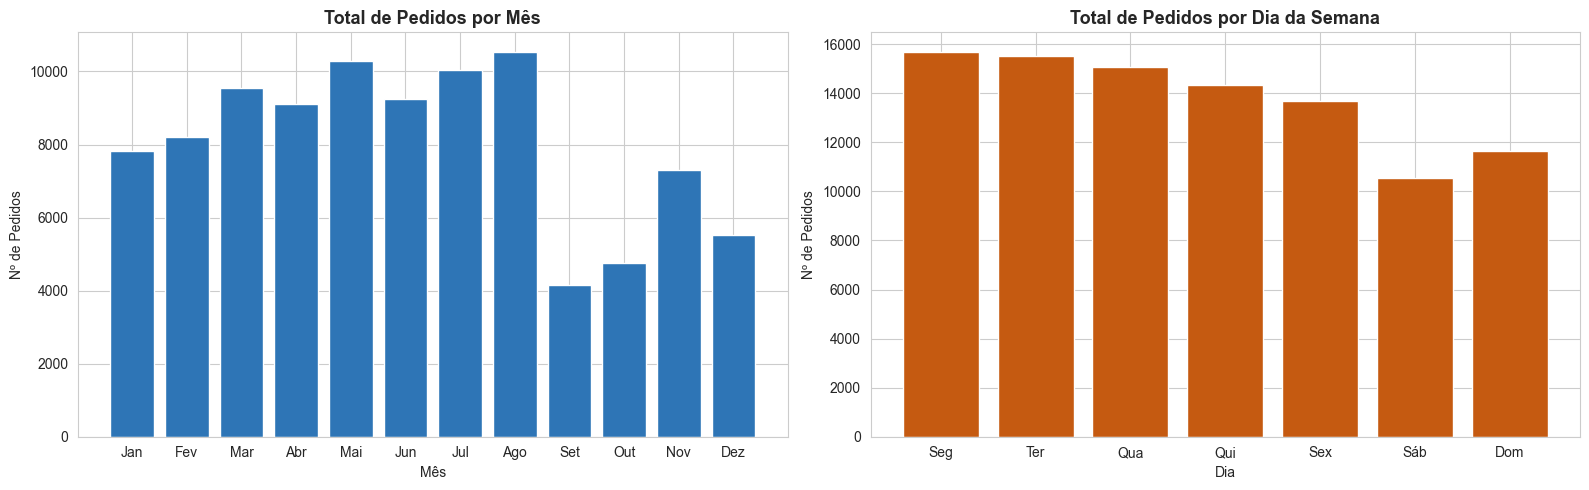

✅ Gráfico salvo em data/processed/


In [8]:
# Agrupamento por mês
por_mes = df.groupby('mes').agg(total_pedidos=('order_id', 'count')).reset_index()
nomes_meses = {1:'Jan',2:'Fev',3:'Mar',4:'Abr',5:'Mai',6:'Jun',
               7:'Jul',8:'Ago',9:'Set',10:'Out',11:'Nov',12:'Dez'}
por_mes['nome_mes'] = por_mes['mes'].map(nomes_meses)

fig, eixos = plt.subplots(1, 2, figsize=(16, 5))

# Sazonalidade mensal
eixos[0].bar(por_mes['nome_mes'], por_mes['total_pedidos'], color=COR_AZUL, edgecolor='white')
eixos[0].set_title('Total de Pedidos por Mês', fontsize=13, fontweight='bold')
eixos[0].set_xlabel('Mês')
eixos[0].set_ylabel('Nº de Pedidos')

# Por dia da semana
ordem_dias_en = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
nomes_dias_pt = ['Seg','Ter','Qua','Qui','Sex','Sáb','Dom']
por_dia = df.groupby('dia_semana').size().reindex(ordem_dias_en)
eixos[1].bar(nomes_dias_pt, por_dia.values, color=COR_LARANJA, edgecolor='white')
eixos[1].set_title('Total de Pedidos por Dia da Semana', fontsize=13, fontweight='bold')
eixos[1].set_xlabel('Dia')
eixos[1].set_ylabel('Nº de Pedidos')

plt.tight_layout()
plt.savefig('../data/processed/sazonalidade.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico salvo em data/processed/')

## 7. Receita Mensal

In [9]:
# Somando pagamentos por pedido
receita_por_pedido = pagamentos.groupby('order_id')['payment_value'].sum().reset_index()
receita_por_pedido.columns = ['order_id', 'valor_total']

df_receita = df.merge(receita_por_pedido, on='order_id', how='left')

receita_mensal = (
    df_receita.groupby('ano_mes')
    .agg(receita_total=('valor_total', 'sum'), qtd_pedidos=('order_id', 'count'))
    .reset_index()
)
receita_mensal['ano_mes_str']  = receita_mensal['ano_mes'].astype(str)
receita_mensal['ticket_medio'] = receita_mensal['receita_total'] / receita_mensal['qtd_pedidos']

fig = make_subplots(specs=[[{'secondary_y': True}]])
fig.add_trace(
    go.Bar(x=receita_mensal['ano_mes_str'], y=receita_mensal['receita_total'],
           name='Receita (R$)', marker_color=COR_AZUL, opacity=0.8),
    secondary_y=False
)
fig.add_trace(
    go.Scatter(x=receita_mensal['ano_mes_str'], y=receita_mensal['ticket_medio'],
               name='Ticket Médio (R$)', line=dict(color=COR_LARANJA, width=2.5), mode='lines+markers'),
    secondary_y=True
)
fig.update_layout(
    title='💰 Receita Mensal e Ticket Médio — Olist',
    template='plotly_white',
    hovermode='x unified'
)
fig.update_yaxes(title_text='Receita Total (R$)', secondary_y=False)
fig.update_yaxes(title_text='Ticket Médio (R$)', secondary_y=True)
fig.show()

## 8. Top Categorias por Volume de Pedidos

In [10]:
# Unindo itens + produtos + tradução de categorias
itens_com_categoria = itens_pedido.merge(
    produtos[['product_id', 'product_category_name']], on='product_id', how='left'
)
itens_com_categoria = itens_com_categoria.merge(traducao_categ, on='product_category_name', how='left')

# Somente pedidos entregues
itens_entregues = itens_com_categoria[itens_com_categoria['order_id'].isin(df['order_id'])]

top_categorias = (
    itens_entregues.groupby('product_category_name_english')
    .agg(total_pedidos=('order_id', 'count'))
    .sort_values('total_pedidos', ascending=False)
    .head(15)
    .reset_index()
)

fig = px.bar(
    top_categorias.sort_values('total_pedidos'),
    x='total_pedidos',
    y='product_category_name_english',
    orientation='h',
    title='🏆 Top 15 Categorias por Volume de Pedidos',
    labels={'total_pedidos': 'Nº de Pedidos', 'product_category_name_english': 'Categoria'},
    color='total_pedidos',
    color_continuous_scale='Blues'
)
fig.update_layout(template='plotly_white', showlegend=False)
fig.show()

## 9. Salvando Série Temporal Processada

In [11]:
# Salvando série mensal para usar no notebook de modelagem
# Nota: Prophet exige colunas 'ds' e 'y' — mantidas por ser nome do framework
serie_para_exportar = receita_mensal[['ano_mes_str', 'qtd_pedidos', 'receita_total', 'ticket_medio']].copy()
serie_para_exportar.columns = ['ds', 'qtd_pedidos', 'receita_total', 'ticket_medio']
serie_para_exportar['ds'] = pd.to_datetime(serie_para_exportar['ds'])

serie_para_exportar.to_csv('../data/processed/serie_temporal_mensal.csv', index=False)
print(f'✅ Série salva: {len(serie_para_exportar)} meses')
serie_para_exportar.head()

✅ Série salva: 23 meses


,ds,qtd_pedidos,receita_total,ticket_medio
0,2016-09-01,1,0.00,0.000000
1,2016-10-01,265,46566.71,175.723434
2,2016-12-01,1,19.62,19.620000
3,2017-01-01,750,127545.67,170.060893
4,2017-02-01,1653,271298.65,164.125015


## 10. Conclusões da EDA

| Indicador | Observação |
|---|---|
| Período analisado | Set/2016 → Ago/2018 (23 meses) |
| Total de pedidos entregues | 96.478 |
| Tendência geral | Crescimento acelerado: de ~265 pedidos/mês (Out/2016) para ~7.000/mês (2018) |
| Mês de maior demanda | Novembro/2017 — **7.289 pedidos** (Black Friday) |
| Mês de menor demanda | Set e Dez/2016 — dados parciais (1 pedido); descartados no pré-processamento |
| Melhor dia da semana | **Segunda-feira** (15.701 pedidos acumulados) |
| Categoria líder | **bed_bath_table** — Cama, Mesa & Banho (10.953 pedidos) |
| Ticket médio aproximado | **R$ 161,38** |

### Anomalias identificadas para tratamento no pré-processamento

- **Set/2016 e Dez/2016:** apenas 1 pedido registrado — Olist ainda em fase inicial; remover da série.
- **Nov/2016:** ausente na série (nenhum pedido entregue naquele mês).
- **Nov/2017:** pico acentuado de +32% em relação ao mês anterior — Black Friday; modelar como *holiday* no Prophet.
- **Ago/2018:** último mês pode ser parcial — verificar no pré-processamento.

---
**Próximo passo:** `02_preprocessing.ipynb` — limpeza e preparação da série para o modelo Prophet.